In [145]:
# %% Block 1: Import packages and set global parameters
import numpy as np
from numpy.random import default_rng
from scipy.special import exp1
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator, interp1d
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Galactic disc extent (kpc)
R_in, R_out = 3.0, 15.0
# Diffusion parameters
kappa = 0.5          # kpc^2/Gyr
x0 = 0.1             # initial smoothing length (kpc)
t_star = 5.0         # maximum source age (Gyr)
# Spiral structure
m_arms = 2
pitch_angle = 15.0   # degree
pitch_rad = np.deg2rad(pitch_angle)
Theta0 = 0.0
# Modulation amplitude
eta = 1
def h_func(Theta):
    return np.cos(Theta)
# Background rate λ₀(ϖ) = λ₀₀ exp(-ϖ/h_R)
lambda0_0 = 1e3     # kpc^-2 Gyr^-1
h_R = 3.0
# Output (fixed)
Y_val = 1.0
# Computational grid
dx = 0.2
grid_radius = R_out + 1.0

rng = default_rng(42)
print("The settings have been configured.")

The settings have been configured.


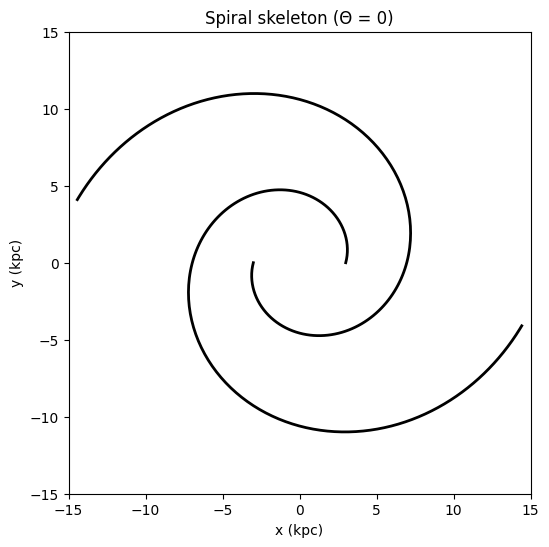

In [146]:
# %% Section 2: Definition of auxiliary functions (spiral phase, source rate, wavenumber)
def spiral_phase(ϖ, φ):
    """The phase of a logarithmic spiral Θ"""
    Phi = (m_arms / np.tan(pitch_rad)) * np.log(ϖ / R_in)
    return Phi - m_arms * φ + Theta0

def lambda_rate(ϖ, φ):
    """Non-uniform event rate λ(ϖ,φ)"""
    lam0 = lambda0_0 * np.exp(-ϖ / h_R)
    #lam0 = lambda0_0
    Theta = spiral_phase(ϖ, φ)
    return lam0 * (1.0 + eta * h_func(Theta))

def k_perp(ϖ):
    """Local cantilever vertical wavenumber k⊥"""
    dPhi = (m_arms / np.tan(pitch_rad)) / ϖ
    return np.sqrt(dPhi**2 + (m_arms / ϖ)**2)

# Visualising a spiral pattern: Draw the ridge line for Θ = 0
φ_plot = np.linspace(0, 2*np.pi, 500)
ϖ_plot = np.linspace(R_in, R_out, 200)
fig, ax = plt.subplots(figsize=(6,6))
for k in range(m_arms):
    φ0 = (Theta0 + 2*np.pi*k) / m_arms
    # 解 Φ(ϖ) - m φ + Θ0 = 0 -> φ = (Φ(ϖ)+Θ0+2πk)/m
    φ_sp = ((m_arms / np.tan(pitch_rad)) * np.log(ϖ_plot / R_in) + Theta0 + 2*np.pi*k) / m_arms
    ax.plot(ϖ_plot * np.cos(φ_sp), ϖ_plot * np.sin(φ_sp), 'k-', lw=2)
ax.set_xlim(-R_out, R_out)
ax.set_ylim(-R_out, R_out)
ax.set_aspect('equal')
ax.set_title('Spiral skeleton (Θ = 0)')
ax.set_xlabel('x (kpc)'); ax.set_ylabel('y (kpc)')
plt.show()

Expected number of events: 196600, In fact: 196975


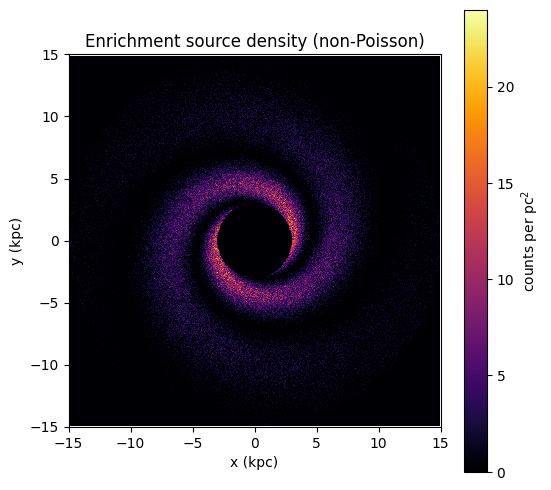

The abundance field calculation has been completed.


In [147]:
# %% Block 3: Generating synthetic galaxies (non-uniform Poisson events + Gaussian diffusion)
# --- Expected number of events ---
Nr, Nphi = 200, 400
ϖ_edges = np.linspace(R_in, R_out, Nr+1)
φ_edges = np.linspace(0, 2*np.pi, Nphi+1)
ϖ_c = 0.5*(ϖ_edges[:-1] + ϖ_edges[1:])
φ_c = 0.5*(φ_edges[:-1] + φ_edges[1:])
dϖ = np.diff(ϖ_edges)
dφ = 2*np.pi / Nphi
area_cells = (ϖ_c * dϖ)[:, None] * dφ
lam_grid = np.array([[lambda_rate(ϖ_c[ir], φ_c[ip]) for ip in range(Nphi)] for ir in range(Nr)])
expected_total = np.sum(lam_grid * area_cells) * t_star
N_events = rng.poisson(expected_total)
print(f"Expected number of events: {expected_total:.0f}, In fact: {N_events}")

# --- Accept-Reject Sampling ---
lam_max = np.max(lam_grid)
N_cand = int(3 * N_events)
ϖ_cand = np.sqrt(rng.uniform(R_in**2, R_out**2, N_cand))
φ_cand = rng.uniform(0, 2*np.pi, N_cand)
lam_cand = lambda_rate(ϖ_cand, φ_cand)
accept = rng.uniform(size=N_cand) < lam_cand / lam_max
events_ϖ = ϖ_cand[accept]
events_φ = φ_cand[accept]
while len(events_ϖ) < N_events:
    extra = N_events - len(events_ϖ)
    ϖ_ex = np.sqrt(rng.uniform(R_in**2, R_out**2, extra*2))
    φ_ex = rng.uniform(0, 2*np.pi, extra*2)
    lam_ex = lambda_rate(ϖ_ex, φ_ex)
    acc = rng.uniform(size=len(ϖ_ex)) < lam_ex / lam_max
    events_ϖ = np.concatenate([events_ϖ, ϖ_ex[acc]])
    events_φ = np.concatenate([events_φ, φ_ex[acc]])
events_ϖ = events_ϖ[:N_events]
events_φ = events_φ[:N_events]
ages = rng.uniform(0, t_star, N_events)
event_x = events_ϖ * np.cos(events_φ)
event_y = events_ϖ * np.sin(events_φ)

# Visualisation of event distribution: two-dimensional histogram (high resolution)
bins = 500
fig, ax = plt.subplots(figsize=(6,6))
weights = np.full(len(event_x), 1/(R_out*1e3/bins))
h = ax.hist2d(event_x, event_y, bins=bins, cmap='inferno')
plt.colorbar(h[3], ax=ax, label=r'counts per pc$^2$')
ax.set_xlim(-R_out, R_out)
ax.set_ylim(-R_out, R_out)
ax.set_aspect('equal')
ax.set_title('Enrichment source density (non-Poisson)')
ax.set_xlabel('x (kpc)'); ax.set_ylabel('y (kpc)')
plt.show()

# --- Calculation of abundance fields using Gaussian diffusion Z(x,y) ---
grid_x = np.arange(-grid_radius, grid_radius+dx, dx)
grid_y = np.arange(-grid_radius, grid_radius+dx, dx)
X, Y = np.meshgrid(grid_x, grid_y)
Z = np.zeros_like(X)
for i in range(N_events):
    Bs = 0.5*x0**2 + kappa * ages[i]
    cutoff = 5.0 * np.sqrt(2*Bs)
    dist2 = (X - event_x[i])**2 + (Y - event_y[i])**2
    mask = dist2 < cutoff**2
    Z[mask] += Y_val * np.exp(-dist2[mask]/(4*Bs)) / (4*np.pi*Bs)
print("The abundance field calculation has been completed.")

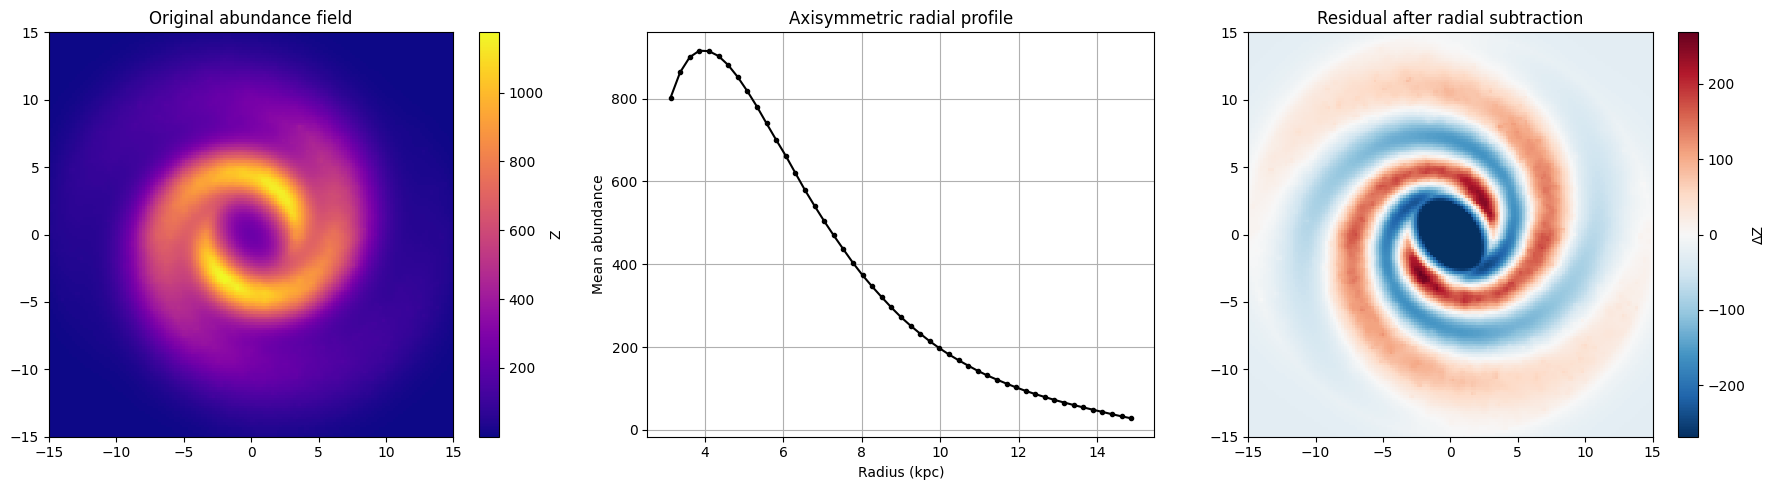

In [148]:
# %% Block 4: Subtraction of the radial gradient
R_grid = np.sqrt(X**2 + Y**2)
disk_mask = (R_grid >= R_in) & (R_grid <= R_out)

# Divide the data into radial bins and calculate the average abundance within each ring
R_bins = np.linspace(R_in, R_out, 50)
R_c = 0.5 * (R_bins[:-1] + R_bins[1:])
Z_rad = np.array([
    np.mean(Z[(R_grid >= rl) & (R_grid < rh)])
    for rl, rh in zip(R_bins[:-1], R_bins[1:])
])

# Interpolation is used to obtain a smooth radial background field
f_mean = interp1d(R_c, Z_rad, kind='linear',
                  bounds_error=False, fill_value=(Z_rad[0], Z_rad[-1]))
Z_bg = f_mean(R_grid)

# Fluctuation field = Original field – axisymmetric radial background
Z_res = Z - Z_bg

# Visualisation: The left-hand figure shows the original abundance field, 
# the middle figure shows the radial gradient, 
# and the right-hand figure shows the fluctuation field.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original abundance field
im1 = axes[0].pcolormesh(X, Y, Z, cmap='plasma', shading='auto')
plt.colorbar(im1, ax=axes[0], label='Z')
axes[0].set_title('Original abundance field')
axes[0].set_xlim(-R_out, R_out)
axes[0].set_ylim(-R_out, R_out)
axes[0].set_aspect('equal')

# Radial gradient
axes[1].plot(R_c, Z_rad, 'ko-', markersize=3)
axes[1].set_xlabel('Radius (kpc)')
axes[1].set_ylabel('Mean abundance')
axes[1].set_title('Axisymmetric radial profile')
axes[1].grid(True)

# Fluctuation
vmax = np.nanmax(np.abs(Z_res[disk_mask]))
im2 = axes[2].pcolormesh(X, Y, Z_res, cmap='RdBu_r', shading='auto',
                         vmin=-vmax, vmax=vmax)
plt.colorbar(im2, ax=axes[2], label='ΔZ')
axes[2].set_title('Residual after radial subtraction')
axes[2].set_xlim(-R_out, R_out)
axes[2].set_ylim(-R_out, R_out)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

In [149]:
# %% Section 5: The two-point correlation function ξ_2(\varpi_m, r) in the simulation
radii_test = [3.5, 5.5, 7.5, 9.5, 11.5, 13.5]   # kpc
r_max = 10.0
r_bins = np.linspace(0.1, r_max, 30)
r_centers = 0.5*(r_bins[:-1] + r_bins[1:])
num_pairs = 50000
interp_Z = RegularGridInterpolator((grid_x, grid_y), Z_res.T, bounds_error=False, fill_value=0.0)

sim_corr = {}
for ϖ_m in radii_test:
    mid_φ = rng.uniform(0, 2*np.pi, num_pairs)
    sep_ψ = rng.uniform(0, 2*np.pi, num_pairs)   # pitch angle
    sep_r = rng.uniform(r_bins[0], r_bins[-1], num_pairs)
    mid_x = ϖ_m * np.cos(mid_φ)
    mid_y = ϖ_m * np.sin(mid_φ)
    dx = 0.5*sep_r*np.cos(sep_ψ); dy = 0.5*sep_r*np.sin(sep_ψ)
    xm, ym = mid_x - dx, mid_y - dy
    xp, yp = mid_x + dx, mid_y + dy
    valid = (np.hypot(xm,ym)>=R_in) & (np.hypot(xm,ym)<=R_out) & (np.hypot(xp,yp)>=R_in) & (np.hypot(xp,yp)<=R_out)
    Zm = interp_Z(np.column_stack((xm[valid], ym[valid])))
    Zp = interp_Z(np.column_stack((xp[valid], yp[valid])))
    r_valid = sep_r[valid]
    corr_vals = np.full(len(r_centers), np.nan)
    for i, (rl, rh) in enumerate(zip(r_bins[:-1], r_bins[1:])):
        mask = (r_valid>=rl) & (r_valid<rh)
        if np.sum(mask) > 10:
            # The radial profile has already been subtracted. Do not subtract
            # a fresh mean in each separation bin, because that would remove
            # part of the fixed spiral mean-field covariance C_M.
            z1 = Zm[mask]
            z2 = Zp[mask]
            denom = np.sqrt(np.mean(z1**2) * np.mean(z2**2))
            corr_vals[i] = np.mean(z1*z2) / denom if denom > 0 else np.nan
    sim_corr[ϖ_m] = corr_vals
print("The correlation measurement of the numerical simulation has been completed.")

The correlation measurement of the numerical simulation has been completed.


In [150]:
# %% Block 6: KTZ prediction
from functools import lru_cache

p0_val = x0**2
p_ast_val = x0**2 + 2*kappa*t_star

@lru_cache(maxsize=None)
def I0(r):
    if r==0: return 0.5*np.log(p_ast_val/p0_val)
    # I0 = 1/2 [E1(r^2/4p_ast) - E1(r^2/4p0)] > 0.
    return 0.5*(exp1(r**2/(4*p_ast_val)) - exp1(r**2/(4*p0_val)))

@lru_cache(maxsize=None)
def InP(r, Qn):
    f = lambda p: 0.5/p * np.exp(-r**2/(4*p) - Qn**2*p/4)
    I, _ = quad(f, p0_val, p_ast_val, limit=100)
    return I

@lru_cache(maxsize=None)
def Tn(Qn):
    if Qn==0: return t_star
    return np.exp(-0.5*x0**2*Qn**2) * (1-np.exp(-kappa*t_star*Qn**2)) / (kappa*Qn**2)

def local_cov_components(ϖ_m, phi_m, r, psi):
    Theta_m = spiral_phase(ϖ_m, phi_m)
    Q1 = k_perp(ϖ_m)
    dPhi = (m_arms/np.tan(pitch_rad))/ϖ_m
    grad_x = dPhi*np.cos(phi_m) + (m_arms/ϖ_m)*np.sin(phi_m)
    grad_y = dPhi*np.sin(phi_m) - (m_arms/ϖ_m)*np.cos(phi_m)
    grad = np.array([grad_x, grad_y])
    r_vec = r*np.array([np.cos(psi), np.sin(psi)])

    # Linearized endpoint phases: Theta_+ - Theta_- = grad(Theta) dot r_vec.
    dot = np.dot(grad, r_vec)
    Theta_minus = Theta_m - 0.5*dot
    Theta_plus  = Theta_m + 0.5*dot

    S1_m = np.cos(Theta_m)
    S1_mi = np.cos(Theta_minus)
    S1_pl = np.cos(Theta_plus)
    lam_local = lambda0_0 * np.exp(-ϖ_m/h_R)
    R_val = 4*np.pi*kappa*lam_local*eta**2
    T1 = Tn(Q1)

    num = I0(r) + eta*InP(r,Q1)*S1_m + R_val * T1**2 * S1_mi * S1_pl
    var_m = I0(0) + eta*InP(0,Q1)*S1_mi + R_val*(T1*S1_mi)**2
    var_p = I0(0) + eta*InP(0,Q1)*S1_pl + R_val*(T1*S1_pl)**2
    return num, var_m, var_p

def local_xi1(ϖ_m, phi_m, r, psi):
    num, var_m, var_p = local_cov_components(ϖ_m, phi_m, r, psi)
    if var_m<=0 or var_p<=0: return np.nan
    return num/np.sqrt(var_m*var_p)

def endpoint_window_ok(ϖ_m, phi_m, r, psi):
    mid_x = ϖ_m*np.cos(phi_m)
    mid_y = ϖ_m*np.sin(phi_m)
    hx = 0.5*r*np.cos(psi)
    hy = 0.5*r*np.sin(psi)
    rm = np.hypot(mid_x - hx, mid_y - hy)
    rp = np.hypot(mid_x + hx, mid_y + hy)
    return (R_in <= rm <= R_out) and (R_in <= rp <= R_out)

def xi2_KTZ(ϖ_m, r, Nphi=40, Npsi=40, estimator="pair_product"):
    """Windowed KTZ prediction.

    estimator="pair_product" matches the simulation estimator in Block 5:
    <Z_- Z_+>/sqrt(<Z_-^2><Z_+^2>) after radial subtraction.
    estimator="mean_xi" returns the paper definition, i.e. the windowed
    arithmetic mean of local xi_1 values.
    """
    phi_arr = np.linspace(0,2*np.pi,Nphi,endpoint=False)
    psi_arr = np.linspace(0,2*np.pi,Npsi,endpoint=False)
    xi_vals, nums, vars_m, vars_p = [], [], [], []
    for phi in phi_arr:
        for psi in psi_arr:
            if not endpoint_window_ok(ϖ_m, phi, r, psi):
                continue
            num, var_m, var_p = local_cov_components(ϖ_m, phi, r, psi)
            if var_m<=0 or var_p<=0:
                continue
            nums.append(num); vars_m.append(var_m); vars_p.append(var_p)
            xi_vals.append(num/np.sqrt(var_m*var_p))
    if not nums:
        return np.nan
    if estimator == "mean_xi":
        return np.mean(xi_vals)
    return np.mean(nums)/np.sqrt(np.mean(vars_m)*np.mean(vars_p))

wkb_corr = {}
for ϖ_m in radii_test:
    pred = [xi2_KTZ(ϖ_m, r, estimator="pair_product") for r in r_centers]
    wkb_corr[ϖ_m] = np.array(pred)
print("Theoretical prediction with KTZ has been completed.")


Theoretical prediction with KTZ has been completed.


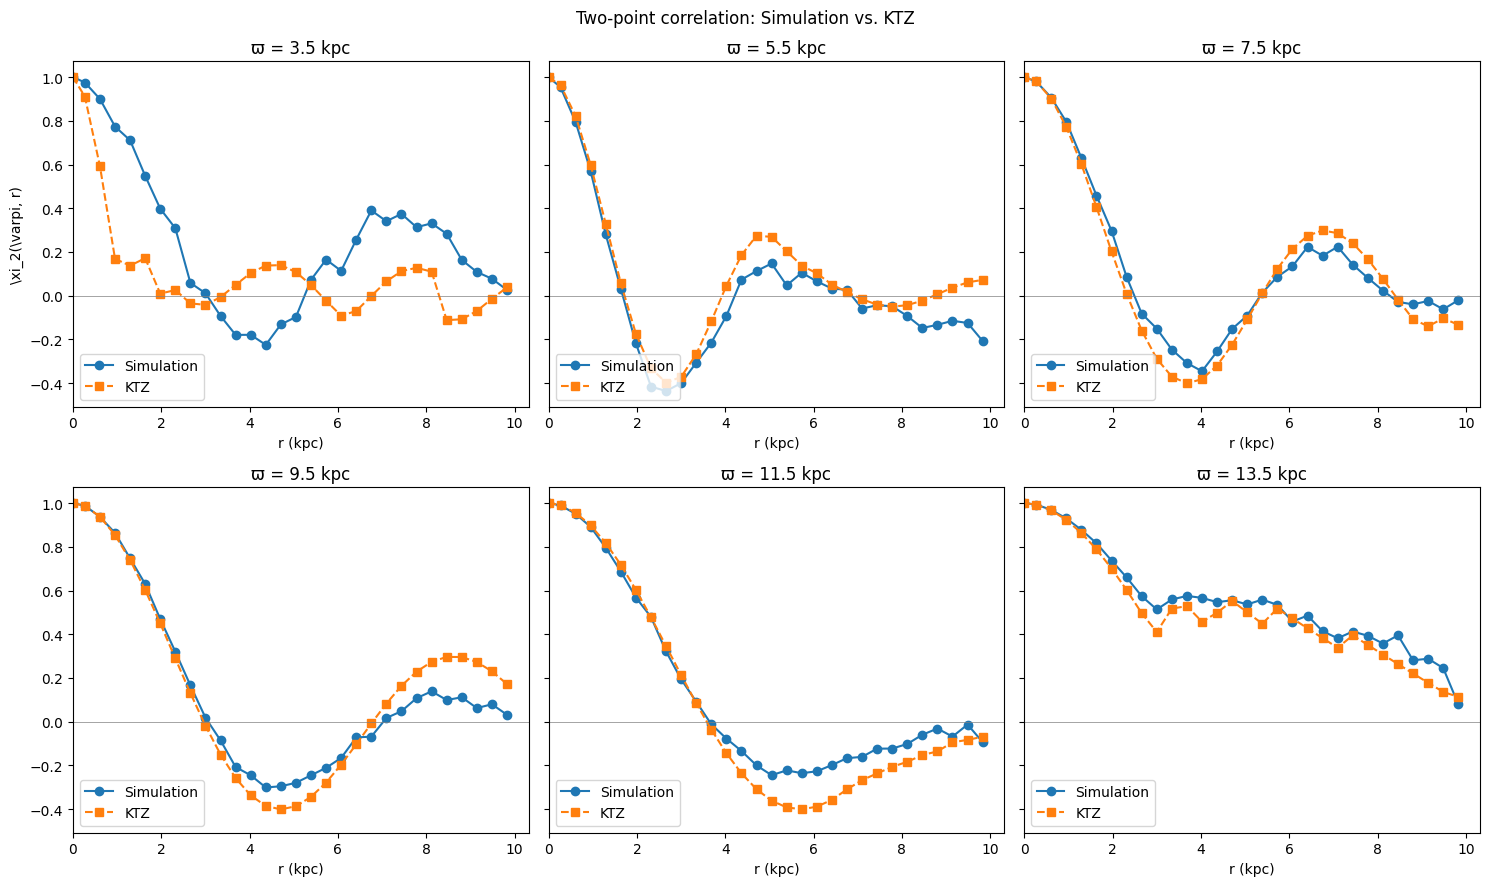

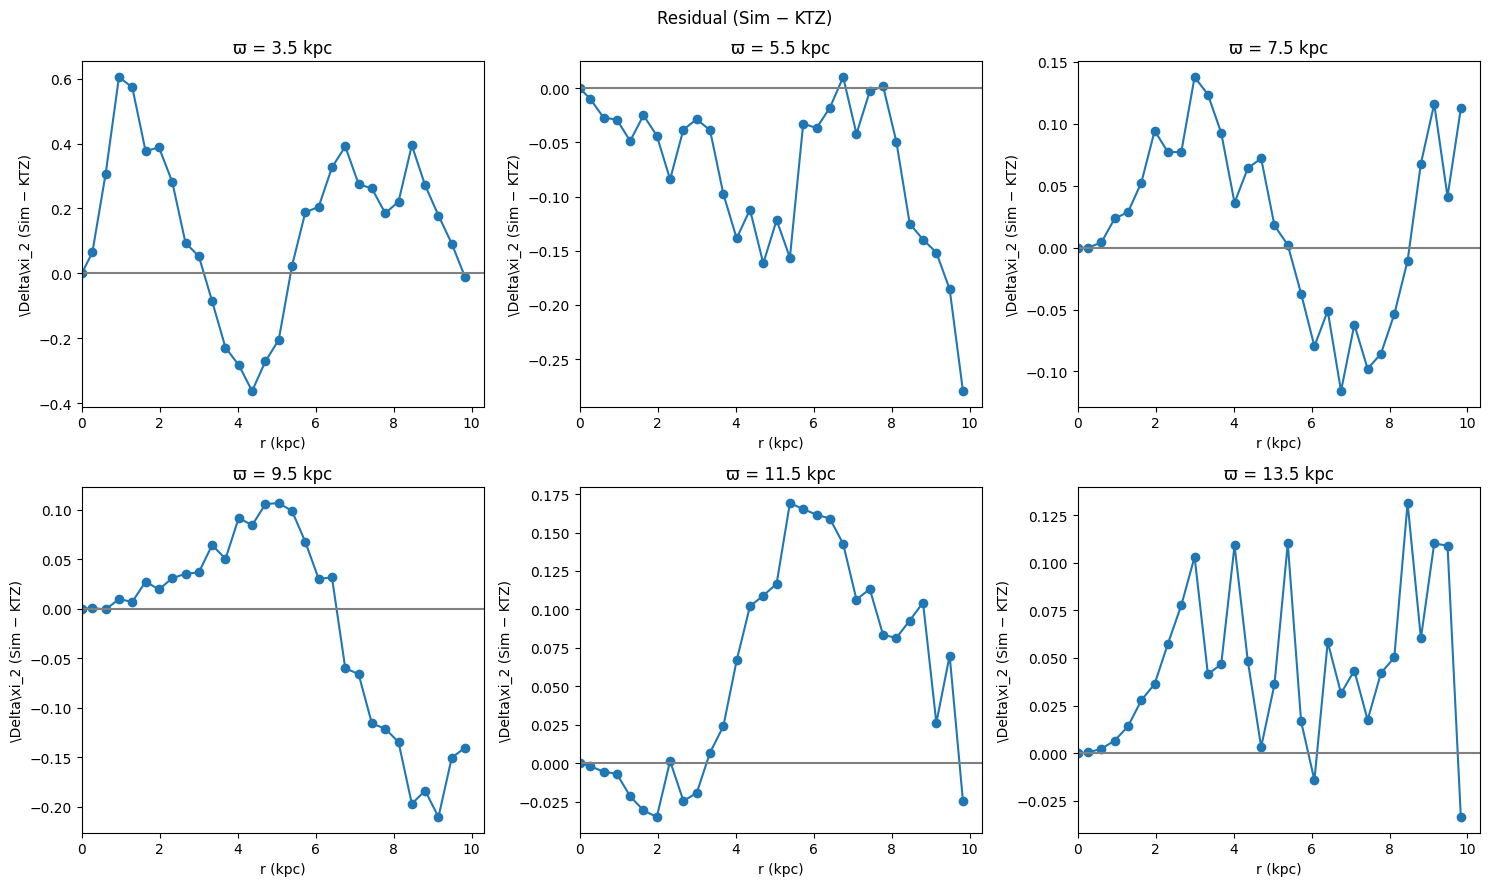

In [151]:
# %% Block 7a: Comparison of correlation functions
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
axes = axes.flatten()

for ax, ϖ_m in zip(axes, radii_test):
    r_plot = np.concatenate([[0.0], r_centers])
    sim_plot = np.concatenate([[1.0], sim_corr[ϖ_m]])
    wkb_plot = np.concatenate([[1.0], wkb_corr[ϖ_m]])

    ax.plot(r_plot, sim_plot, 'o-', label='Simulation')
    ax.plot(r_plot, wkb_plot, 's--', label='KTZ')
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_title(f'ϖ = {ϖ_m} kpc')
    ax.set_xlabel('r (kpc)')
    ax.set_xlim(left=0)
    ax.legend(loc='lower left')

axes[0].set_ylabel(r'\xi_2(\varpi, r)')
fig.suptitle('Two‑point correlation: Simulation vs. KTZ')
plt.tight_layout()
plt.show()

# %% Block 7b: Residual
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, ϖ_m in zip(axes, radii_test):
    r_plot = np.concatenate([[0.0], r_centers])
    diff = np.concatenate([[0.0], sim_corr[ϖ_m] - wkb_corr[ϖ_m]])

    ax.plot(r_plot, diff, 'o-')
    ax.axhline(0, color='grey')
    ax.set_title(f'ϖ = {ϖ_m} kpc')
    ax.set_xlabel('r (kpc)')
    ax.set_ylabel(r'\Delta\xi_2 (Sim − KTZ)')
    ax.set_xlim(left=0)

fig.suptitle('Residual (Sim − KTZ)')
plt.tight_layout()
plt.show()

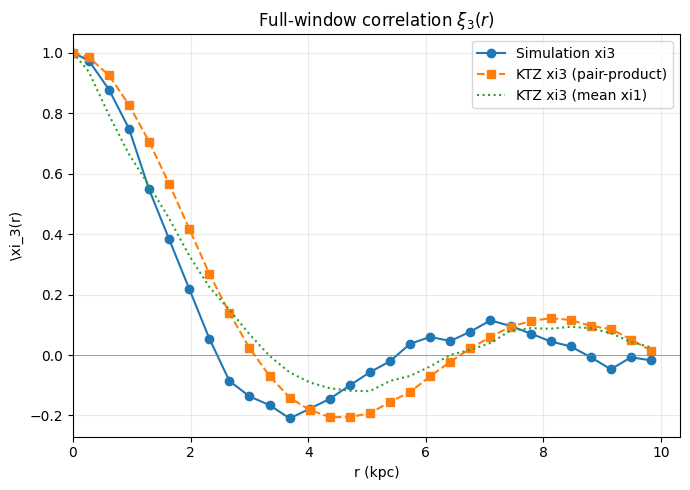

In [152]:
# %% Block 8: xi3(r) over the full observing window
# xi3 averages over all valid midpoint radii and separation directions.
# The simulation and KTZ curves both use the pair-product estimator so that
# they are directly comparable after radial-background subtraction.

num_pairs_xi3 = 150000
mid_R = np.sqrt(rng.uniform(R_in**2, R_out**2, num_pairs_xi3))
mid_phi = rng.uniform(0, 2*np.pi, num_pairs_xi3)
sep_psi = rng.uniform(0, 2*np.pi, num_pairs_xi3)
sep_r = rng.uniform(r_bins[0], r_bins[-1], num_pairs_xi3)

mid_x = mid_R*np.cos(mid_phi)
mid_y = mid_R*np.sin(mid_phi)
hx = 0.5*sep_r*np.cos(sep_psi)
hy = 0.5*sep_r*np.sin(sep_psi)
xm, ym = mid_x - hx, mid_y - hy
xp, yp = mid_x + hx, mid_y + hy
valid = (
    (np.hypot(xm,ym) >= R_in) & (np.hypot(xm,ym) <= R_out) &
    (np.hypot(xp,yp) >= R_in) & (np.hypot(xp,yp) <= R_out)
)
Zm = interp_Z(np.column_stack((xm[valid], ym[valid])))
Zp = interp_Z(np.column_stack((xp[valid], yp[valid])))
r_valid = sep_r[valid]

xi3_sim = np.full(len(r_centers), np.nan)
for i, (rl, rh) in enumerate(zip(r_bins[:-1], r_bins[1:])):
    mask = (r_valid >= rl) & (r_valid < rh)
    if np.sum(mask) > 10:
        z1 = Zm[mask]
        z2 = Zp[mask]
        denom = np.sqrt(np.mean(z1**2) * np.mean(z2**2))
        xi3_sim[i] = np.mean(z1*z2) / denom if denom > 0 else np.nan

def xi3_KTZ(r, Nvarpi=30, Nphi=20, Npsi=20, estimator="pair_product"):
    # Equal spacing in R^2 gives equal-area annular samples for the midpoint.
    rho2_edges = np.linspace(R_in**2, R_out**2, Nvarpi+1)
    varpi_arr = np.sqrt(0.5*(rho2_edges[:-1] + rho2_edges[1:]))
    phi_arr = np.linspace(0, 2*np.pi, Nphi, endpoint=False)
    psi_arr = np.linspace(0, 2*np.pi, Npsi, endpoint=False)
    xi_vals, nums, vars_m, vars_p = [], [], [], []
    for varpi in varpi_arr:
        for phi in phi_arr:
            for psi in psi_arr:
                if not endpoint_window_ok(varpi, phi, r, psi):
                    continue
                num, var_m, var_p = local_cov_components(varpi, phi, r, psi)
                if var_m <= 0 or var_p <= 0:
                    continue
                nums.append(num); vars_m.append(var_m); vars_p.append(var_p)
                xi_vals.append(num/np.sqrt(var_m*var_p))
    if not nums:
        return np.nan
    if estimator == "mean_xi":
        return np.mean(xi_vals)
    return np.mean(nums)/np.sqrt(np.mean(vars_m)*np.mean(vars_p))

xi3_ktz = np.array([xi3_KTZ(r, estimator="pair_product") for r in r_centers])
xi3_ktz_meanxi = np.array([xi3_KTZ(r, estimator="mean_xi") for r in r_centers])

fig, ax = plt.subplots(figsize=(7, 5))
r_plot = np.concatenate([[0.0], r_centers])
sim_plot = np.concatenate([[1.0], xi3_sim])
ktz_plot = np.concatenate([[1.0], xi3_ktz])
ktz_meanxi_plot = np.concatenate([[1.0], xi3_ktz_meanxi])

ax.plot(r_plot, sim_plot, 'o-', label='Simulation xi3')
ax.plot(r_plot, ktz_plot, 's--', label='KTZ xi3 (pair-product)')
ax.plot(r_plot, ktz_meanxi_plot, ':', color='C2', label='KTZ xi3 (mean xi1)')
ax.axhline(0, color='grey', lw=0.5)
ax.set_xlabel('r (kpc)')
ax.set_ylabel(r'\xi_3(r)')
ax.set_xlim(left=0)
ax.set_title(r'Full-window correlation $\xi_3(r)$')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
